In [1]:
import seaborn
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from typing import Dict, List, Tuple

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [2]:
import torch
from torch.utils.data import DataLoader

from data.dataset import SUMODataset
from src.blocks.gcn import GCN
from src.blocks.gat import GAT
from src.models.mapEncoder import SpatialEncoder
from src.blocks.gru import TemporalEncoder
from src.models.mapEncoder import SpatioTemporalConditioner
from src.flowMatching import VelocityVectorField, FlowMatchingModel, predict, Simulator
from src.utils import check_gpu, run_training, dataset_split
from src.models.normalizer import MapNormalizer

/mnt/external1/irene/sumo-stgcn/src


/mnt/external1/irene/sumo-stgcn/.venv-cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/mnt/external1/irene/sumo-stgcn


In [3]:
import torch

data = torch.load(
    "/mnt/external1/irene/sumo-stgcn/data/built_dataset/processed/data_273.pt",
    weights_only=False,  # Set to False if loading PyTorch Geometric / custom data objects
)

print(type(data))
print(data)

<class 'torch_geometric.data.data.Data'>
Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3])


In [4]:
# import pandas as pd

# # If it's a PyTorch Geometric Data object with node/edge features:
# df = pd.DataFrame(data.x.cpu().numpy())

# # Or if it is a dictionary of 1D/2D tensors:
# df = pd.DataFrame({k: v.cpu().numpy() for k, v in data.items()})

In [5]:
!nvidia-smi

Mon Sep 21 11:52:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro GV100                   On  |   00000000:21:00.0 Off |                  Off |
| 30%   42C    P2             24W /  250W |       4MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!python -c "import torch; print(torch.version.cuda)"

12.1


In [ ]:
import os
import sys
import torch
from torch.utils.data import DataLoader
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print(f"project root: {ROOT}")

project root: /mnt/external1/irene/sumo-stgcn


In [8]:
# setup
WINDOW = 6
EPOCHS = 3000
device = check_gpu()

# Dataset split
# TODO - normalize x_dyn in preprocessing
dataset = SUMODataset(root=f"{ROOT}/data/built_dataset", window=WINDOW)
train_set, val_set, test_set = dataset_split(dataset, window=WINDOW, train_fraction=0.6, val_fraction=0.2, test_fraction=0.2)


print("len(dataset):", len(dataset))
print("window:", WINDOW)
print("file .pt trovati:", len(os.listdir(os.path.join(f"{ROOT}/data/built_dataset", "processed"))))

Using device: cuda
len(dataset): 283
window: 6
file .pt trovati: 288


In [9]:
next(iter(dataset))

([Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3]),
  Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3]),
  Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3]),
  Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3]),
  Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3]),
  Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3])],
 tensor([[ 0.6464,  1.6346, -0.0614],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [ 0.3444,  1.7114, -0.0628],
         [ 0.6464,  1.6346, -0.0614],
         [ 0.6464,  1.6466, -0.0615],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.4106, -0.9395, -0.0661],
         [-0.1086,  0.6777, -

In [66]:
from torch_geometric.data import Batch

def collate_batch(batch:list, window:int) -> Tuple[list, torch.Tensor]:
    """
    Gathers `batch_size` indipendent samples  (each sample is made of `window`
    graphs + target) in a unique batch. Useful to process each sample in a unique forward pass.

    For each position w in the window, `batch_size` graphs (one per sample) are aggregated
    in a single Batch (same topology of the original graph).
    Targets are stacked in a unique tensor of size [batch_size, N_nodes, F].
    """
    # batch: list of samples = [([graphs_1], t1), ([g2], t2), ..., ([g_nsample], t_nsample)]
    # with g_n = list of W graphs (Data objects)
    # t_n = target at 
    batched_graphs = []
    for w in range(window):
        graphs_at_w = [sample[0][w] for sample in batch]
        batched_graphs.append(Batch.from_data_list(graphs_at_w))

    targets = torch.stack([sample[1] for sample in batch], dim=0)
    return batched_graphs, targets

# collate fn is useful ot parallelize work and exploit GPU potential

In [ ]:
from functools import partial

collate_fn = partial(collate_batch, window=WINDOW) 
# PASSA PARAMETRO AGGIUNTIVO E COLLATE_BATCH, CHE IN DATALOADER RICEVE SOLO IL BATCH COME INUT
train_loader = DataLoader(train_set, batch_size=16, shuffle=True, collate_fn=collate_fn) # shuffle only training set
val_loader = DataLoader(val_set, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=8, shuffle=False, collate_fn=collate_fn)


In [68]:
# Build dataloaders
# collate custom to deactivate automatic batching - DataLoader can't batch (list[Data], Tensor)
# collate_fn = lambda batch: batch[0]
"""Collate function: rule for DataLoader definition."""
# train_loader = DataLoader(train_set, batch_size=1, shuffle=True, collate_fn=collate_fn) # shuffle only training set
# val_loader = DataLoader(val_set, batch_size=1, shuffle=False, collate_fn=collate_fn)
# test_loader = DataLoader(test_set, batch_size=1, shuffle=False, collate_fn=collate_fn)

# dimensions
node_in_dim = 4 + 3 # x_static + x_dynamic
gcn_out_dim = 16 # edge_attributes
gat_out_dim = 16 # per-node spatial embedding
temporal_hidden = 32 # cond dimension
feat_dyn_dim = 3 # target: flow, speed, occupancy

gcn = GCN(hidden_dims=[node_in_dim, 32, gcn_out_dim], dropout_prob=0.1)
gat = GAT(hidden_dims=[gcn_out_dim, gat_out_dim], heads=2, edge_dim=6, dropout_prob=0.1)
spatial_encoder = SpatialEncoder(gcn, gat)
temporal_encoder = TemporalEncoder(in_dim=gat_out_dim, hidden_dim=temporal_hidden, num_layers=1)
conditioner = SpatioTemporalConditioner(spatial_encoder, temporal_encoder)

velocity_field = VelocityVectorField(feat_dyn_dim=feat_dyn_dim, cond_dim=temporal_hidden, hidden_dim=64)

# Instantiate the model
model = FlowMatchingModel(conditioner, velocity_field).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# for name, param in model.named_parameters():
#     print(name, param, '\n')

normalizer = MapNormalizer.load(f"{ROOT}/data/built_dataset/normalized/norm_stats.pt").to(device)
sample = train_set[0]   # passa per Subset -> SUMODataset.__getitem__ -> get()
graphs, target = sample
graphs = [g.to(device) for g in graphs]
target = target.to(device)
preds = predict(model, graphs, feat_dyn_dim=3, n_integration_steps=50, n_samples=10)

print(f"preds shape:{preds.shape}")
pred_mean = preds.mean(dim=0) # [N_nodes, 3] — stima puntuale
print(f"preds.mean shape:{pred_mean.shape}")
pred_std = preds.std(dim=0) # [N_nodes, 3] — incertezza per nodo/feature

pred_mean_real = normalizer.inverse(pred_mean)   # torna in veicoli/ora, non z-score
target_real = normalizer.inverse(target)
print("target.shape:", target.shape)

preds shape:torch.Size([10, 1, 234, 3])
preds.mean shape:torch.Size([1, 234, 3])
target.shape: torch.Size([234, 3])


/mnt/external1/irene/sumo-stgcn/src/models/normalizer.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


  0%|          | 1/3000 [00:02<2:13:26,  2.67s/it]

Total number of parameters: 9603
Epoch: 0 | Train Loss: 2.0620 | Val Loss: 1.5280


  0%|          | 11/3000 [00:28<2:08:42,  2.58s/it]

Total number of parameters: 9603


  1%|          | 21/3000 [00:54<2:09:31,  2.61s/it]

...

 99%|█████████▉| 2981/3000 [2:08:37<00:47,  2.52s/it]

Total number of parameters: 9603


100%|█████████▉| 2991/3000 [2:09:02<00:22,  2.52s/it]

Total number of parameters: 9603


100%|██████████| 3000/3000 [2:09:24<00:00,  2.59s/it]


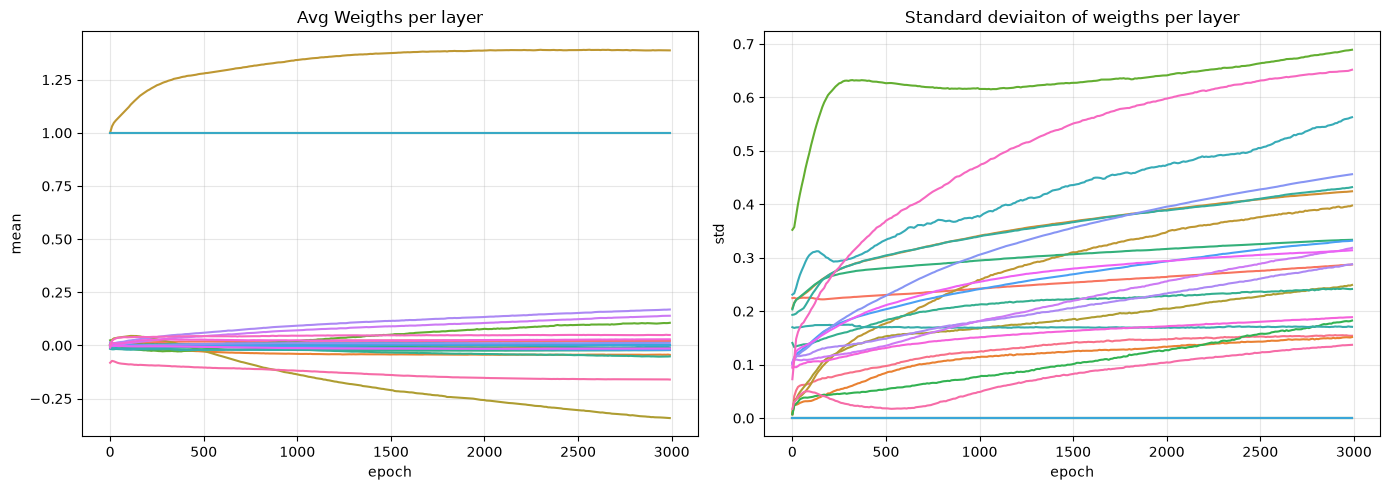

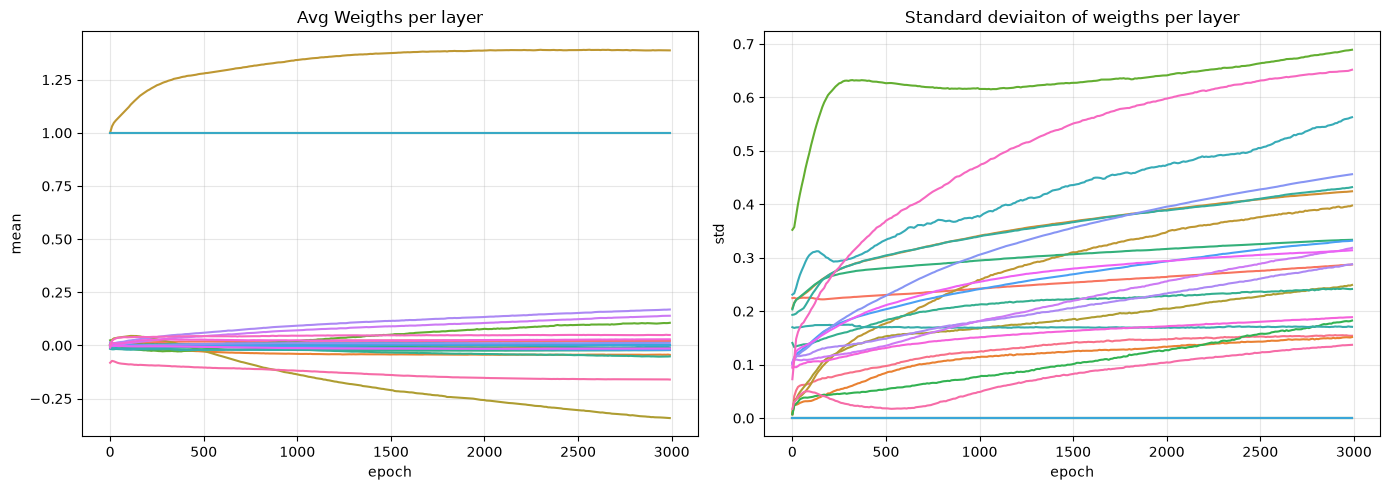

In [69]:
import pandas as pd
from output_eval import collect_params_stats, plot_param_evolution

param_history = []
def tracker(model, epoch):
    if epoch % 10 == 0:  # non ad ogni epoca, per non appesantire
        param_history.append(collect_params_stats(model, epoch))


# Train model
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCHS,
    checkpoint_path="checkpoints/3000_run.pt",
    print_every=50,
    params_tracker=tracker
)

        
plot_param_evolution(pd.concat(param_history, ignore_index=True))

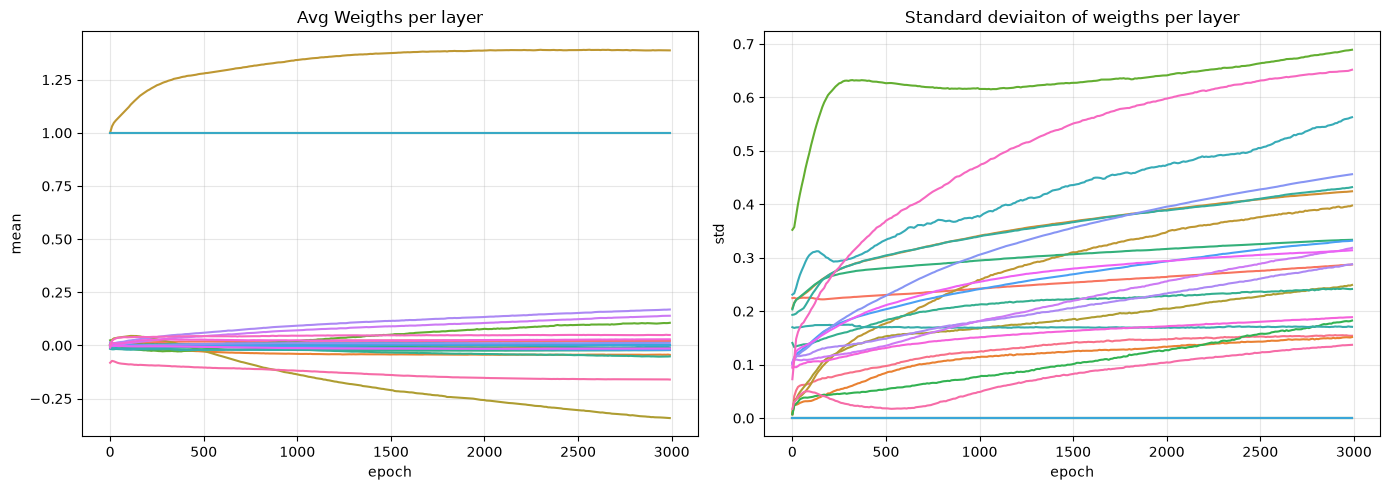

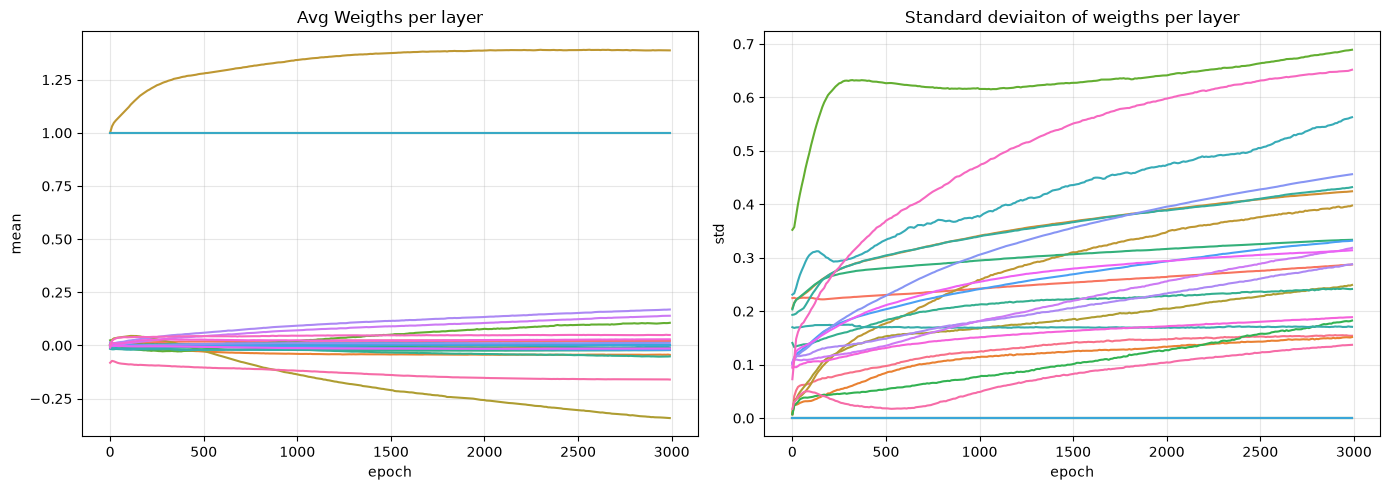

In [87]:
plot_param_evolution(pd.concat(param_history, ignore_index=True))

In [70]:
df_params = pd.concat(param_history, ignore_index=True)

flat = df_params[df_params["std"] < 1e-6]["layer"].unique()
print(flat)

growing = df_params[df_params["epoch"] == df_params["epoch"].max()].nlargest(3, "std")
print(growing[["layer", "std"]])

<ArrowStringArray>
['conditioner.spatial_encoder.gcn.propagations.1.0.weight',
   'conditioner.spatial_encoder.gcn.propagations.1.0.bias',
 'conditioner.spatial_encoder.gat.propagations.0.0.weight',
   'conditioner.spatial_encoder.gat.propagations.0.0.bias']
Length: 4, dtype: str
                                                  layer       std
7483        conditioner.spatial_encoder.gat.convs.0.att  0.689076
7498                        velocity_field.net.2.weight  0.651690
7489  conditioner.spatial_encoder.gat.convs.0.lin_ed...  0.562857


In [71]:
def plot_loss(num_epochs:int, train_loss_values: list, val_loss_values: list, #output_path:str
        ):
        epochs = range(1, num_epochs + 1)
        # Plot the loss curves
        train_loss = [x.item() if isinstance(x, torch.Tensor) else x for x in train_loss_values]
        val_loss = [x.item() if isinstance(x, torch.Tensor) else x for x in val_loss_values]
        plt.plot(epochs, train_loss, label="Train loss")
        plt.plot(epochs, val_loss, label="Test loss")
        plt.title("Training and test loss curves")
        plt.ylabel("Loss")
        plt.xlabel("Epochs")
        plt.legend()
        plt.grid(True, alpha=0.3)
        # plt.savefig(output_path, dpi='300')

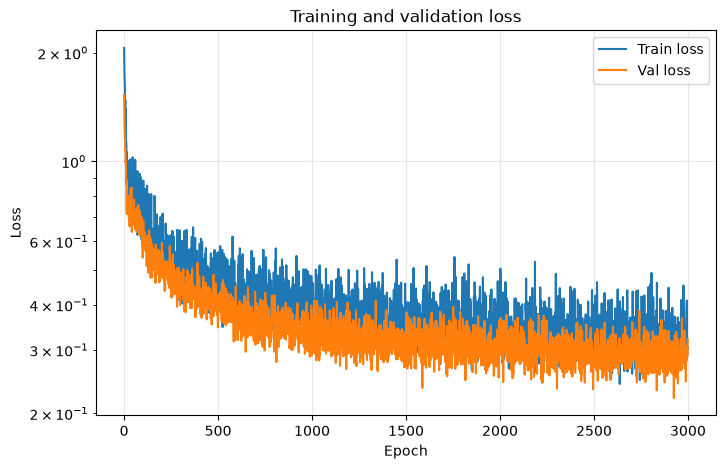

In [72]:
def plot_loss_curves(
    history: Dict[str, List[float]], log_scale: bool = False, out_path: Path = "."
):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["train_loss"], label="Train loss")
    ax.plot(history["val_loss"], label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Training and validation loss")
    if log_scale:
        ax.set_yscale("log")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
plot_loss_curves(history, log_scale=True)

In [73]:
# plot_loss(num_epochs=200, train_loss_values=history['train_loss'], val_loss_values=history['val_loss'])

In [74]:
graphs, target = next(iter(test_loader))
print("target.shape:", target.shape)   # [B_test, 234, 3] o [234, 3]?

target.shape: torch.Size([1, 234, 3])


In [75]:
cond = model.conditioner(graphs)
print("cond:", cond.shape)          # atteso: [1, 234, 16]
B, n_nodes, _ = cond.shape

x0 = torch.randn(B, n_nodes, feat_dyn_dim, device=device)
print("x0:", x0.shape)              # atteso: [1, 234, 3]

out = simulator.simulate(x0, cond, n_integration_steps=n_integration_steps)
print("out:", out.shape)            # atteso: [1, 234, 3]

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat2 in method wrapper_CUDA_mm)

In [76]:
@torch.no_grad()
def evaluate_mae(model, test_loader, normalizer, device="cpu",
                n_integration_steps=100, n_samples=10) -> torch.Tensor:
    """MAE per feature (flow, speed, occupancy), in unità reali, su tutto il test set."""
    model.eval()
    all_mae = []

    for graphs, target in test_loader:
        graphs = [g.to(device) for g in graphs]
        target = target.to(device)

        preds = predict(model, graphs, feat_dyn_dim=3,
                        n_integration_steps=n_integration_steps, n_samples=n_samples)
        # preds.shape: [n_samples, 1, N_nodes, F]
        # squeeze per togliere la dimensione in più del batch (dim: # [n_samples, 1, N_nodes, F], 1 = B)
        pred_mean = preds.mean(dim=0) # [1, N_nodes, F] average over samples
        pred_mean = pred_mean.squeeze(0) # [N_nodes, F]
        pred_mean_real = normalizer.inverse(pred_mean)
        target_real = normalizer.inverse(target)

        all_mae.append((pred_mean_real - target_real).abs().mean(dim=(0,1)))

    return torch.stack(all_mae).mean(dim=0)  # [3]

In [77]:
print(preds.shape, pred_mean.shape, target.shape)

torch.Size([10, 1, 234, 3]) torch.Size([1, 234, 3]) torch.Size([1, 234, 3])


In [78]:
print(normalizer.mu.shape, normalizer.sigma.shape)

torch.Size([1, 1, 3]) torch.Size([1, 1, 3])


In [79]:
import inspect
from src.models.normalizer import MapNormalizer
print(inspect.getsource(MapNormalizer.__init__))

    def __init__(self, map_features: torch.Tensor, eps: float = 1e-8):
        self.eps = eps
        reduce_dims = tuple(range(map_features.dim() - 1))
        n = map_features.numel() // map_features.shape[-1]
        self.mu = torch.mean(map_features, dim=reduce_dims)
        # sqrt(sum(x(i) - mu)^2 / N) 
        self.sigma = torch.sqrt(torch.sum((map_features - self.mu) ** 2, dim=reduce_dims) / n)



In [80]:
import os, time

path = f"{ROOT}/data/built_dataset/normalized/norm_stats.pt"
print("Path caricato:", path)
print("Esiste:", os.path.isfile(path))
print("Ultima modifica:", time.ctime(os.path.getmtime(path)))
print("Ora attuale:      ", time.ctime())

Path caricato: /mnt/external1/irene/sumo-stgcn/data/built_dataset/normalized/norm_stats.pt
Esiste: True
Ultima modifica: Wed Sep 16 18:00:27 2026
Ora attuale:       Sun Sep 20 21:09:06 2026


In [81]:
print("=== Normalizer ===")
print("mu shape:", normalizer.mu.shape)
print("sigma shape:", normalizer.sigma.shape)

print("=== DataLoader class ===")
print(type(test_loader))

print("=== Un solo batch ===")
graphs, target = next(iter(test_loader))
print("target.shape:", target.shape)

graphs = [g.to(device) for g in graphs]
preds = predict(model, graphs, feat_dyn_dim=3, n_integration_steps=50, n_samples=10)
print("preds.shape:", preds.shape)

pred_mean = preds.mean(dim=0)
print("pred_mean.shape:", pred_mean.shape)

pred_mean_real = normalizer.inverse(pred_mean)
print("pred_mean_real.shape:", pred_mean_real.shape)

=== Normalizer ===
mu shape: torch.Size([1, 1, 3])
sigma shape: torch.Size([1, 1, 3])
=== DataLoader class ===
<class 'torch.utils.data.dataloader.DataLoader'>
=== Un solo batch ===
target.shape: torch.Size([1, 234, 3])
preds.shape: torch.Size([10, 1, 234, 3])
pred_mean.shape: torch.Size([1, 234, 3])
pred_mean_real.shape: torch.Size([1, 234, 3])


In [82]:
normalizer = MapNormalizer.load(f"{ROOT}/data/built_dataset/normalized/dynamic_norm_stats.pt").to(device)
mae = evaluate_mae(model, test_loader, normalizer, device=device)

for name, val in zip(["flow", "speed", "occupancy"], mae.tolist()):
    print(f"MAE {name}: {val:.3f}")

/mnt/external1/irene/sumo-stgcn/src/models/normalizer.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


MAE flow: 62.931
MAE speed: 2.607
MAE occupancy: 1.089


In [83]:
naive_mae = []
for graphs, target in test_loader:
    last_observed = graphs[-1].x[:, -3:].to(device)  # x_dynamic al passo t (presente, non target)
    target = target.to(device)

    last_observed_real = normalizer.inverse(last_observed)
    target_real = normalizer.inverse(target)

    naive_mae.append((last_observed_real - target_real).abs().mean(dim=0))

naive_mae = torch.stack(naive_mae).mean(dim=(0,1))
print("Naive MAE (persistenza):", naive_mae)

Naive MAE (persistenza): tensor([36.6151,  1.3514,  0.2620], device='cuda:0')


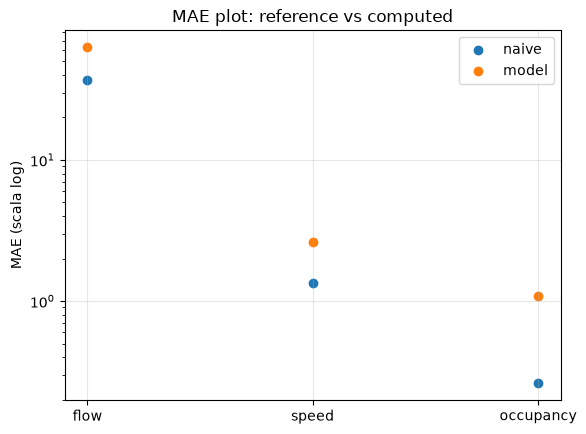

In [84]:
plt.scatter(x=['flow', 'speed', 'occupancy'], y=naive_mae.cpu().numpy(), label='naive')
plt.scatter(x=['flow', 'speed', 'occupancy'], y=mae.cpu().numpy(), label='model')
plt.yscale('log')
plt.ylabel('MAE (scala log)')
plt.title('MAE plot: reference vs computed')
plt.legend()
plt.grid(True, alpha=0.3)

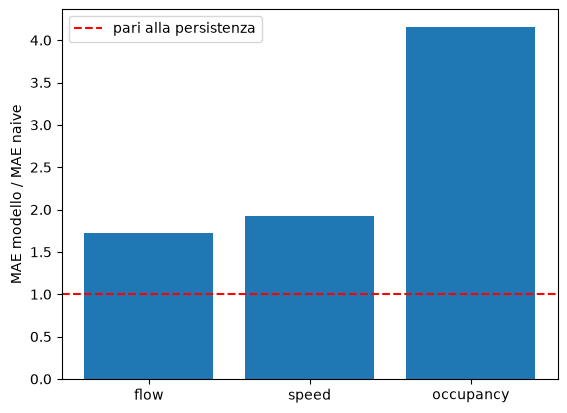

In [85]:
ratio = (mae / naive_mae).cpu().numpy()
plt.bar(['flow', 'speed', 'occupancy'], ratio)
plt.axhline(1.0, color='red', linestyle='--', label='pari alla persistenza')
plt.ylabel('MAE modello / MAE naive')
plt.legend()

In [86]:
graphs, target = next(iter(test_loader))
graphs = [g.to(device) for g in graphs]

preds = predict(model, graphs, feat_dyn_dim=3, n_integration_steps=50, n_samples=10)
print("preds (normalizzato) — occupancy: min", preds[..., 2].min().item(), "max", preds[..., 2].max().item())

preds_real = normalizer.inverse(preds)
print("preds (reale) — occupancy: min", preds_real[..., 2].min().item(), "max", preds_real[..., 2].max().item())

target_real = normalizer.inverse(target.to(device))
print("target (reale) — occupancy: min", target_real[..., 2].min().item(), "max", target_real[..., 2].max().item())

preds (normalizzato) — occupancy: min -0.2626177668571472 max 1.2318713665008545
preds (reale) — occupancy: min -13.763382911682129 max 90.90148162841797
target (reale) — occupancy: min 0.0 max 13.180000305175781
